In [1]:
import pandas as pd
import numpy as np
import math
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.colors
import seaborn as sns
#import plotly.express as px
df = pd.read_csv("customer_info.csv")
df.head()

,customer_id,customer_name,customer_gender,customer_birthdate,kids_home,teens_home,number_complaints,distinct_stores_visited,lifetime_spend_groceries,lifetime_spend_electronics,...,lifetime_spend_fish,lifetime_spend_hygiene,lifetime_spend_videogames,lifetime_spend_petfood,lifetime_total_distinct_products,percentage_of_products_bought_promotion,year_first_transaction,loyalty_card_number,latitude,longitude
0,3,Bsc. Crystal Kitchens,female,02/12/1970 01:36 PM,1.0,1.0,1.0,3.0,11731.0,4553.0,...,213.0,552.0,256.0,384.0,189.0,0.631599,2020.0,1.0,38.794428,-9.215739
1,4,Bsc. Glenda Bauman,female,11/13/1975 06:58 PM,1.0,0.0,0.0,2.0,13694.0,963.0,...,15.0,1880.0,333.0,665.0,130.0,0.149890,2013.0,1.0,38.751711,-9.179611
2,5,Msc. Antonio Campbell,male,09/10/1971 10:07 AM,0.0,0.0,NaN,2.0,12407.0,0.0,...,273.0,507.0,101.0,222.0,81.0,0.069126,2005.0,NaN,38.780678,-9.160656
3,7,John Kelling,male,10/23/1982 11:20 AM,0.0,0.0,2.0,1.0,7493.0,1105.0,...,1083.0,485.0,1656.0,184.0,92.0,0.253609,2021.0,1.0,38.739548,-9.148679
4,8,Arthur Dematteo,male,08/04/1969 10:22 PM,0.0,0.0,3.0,1.0,9187.0,10841.0,...,1015.0,297.0,1258.0,441.0,6.0,0.186569,2021.0,1.0,38.733071,-9.188188


In [2]:
from datetime import datetime
from sklearn.preprocessing import StandardScaler
from sklearn.impute import KNNImputer

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 33038 entries, 0 to 33037
Data columns (total 25 columns):
 #   Column                                   Non-Null Count  Dtype  
---  ------                                   --------------  -----  
 0   customer_id                              33038 non-null  int64  
 1   customer_name                            33038 non-null  object 
 2   customer_gender                          33038 non-null  object 
 3   customer_birthdate                       32873 non-null  object 
 4   kids_home                                32708 non-null  float64
 5   teens_home                               32708 non-null  float64
 6   number_complaints                        32377 non-null  float64
 7   distinct_stores_visited                  32708 non-null  float64
 8   lifetime_spend_groceries                 33038 non-null  float64
 9   lifetime_spend_electronics               32377 non-null  float64
 10  typical_hour                             32377

In [4]:
df.describe()

,customer_id,kids_home,teens_home,number_complaints,distinct_stores_visited,lifetime_spend_groceries,lifetime_spend_electronics,typical_hour,lifetime_spend_vegetables,lifetime_spend_nonalcohol_drinks,...,lifetime_spend_fish,lifetime_spend_hygiene,lifetime_spend_videogames,lifetime_spend_petfood,lifetime_total_distinct_products,percentage_of_products_bought_promotion,year_first_transaction,loyalty_card_number,latitude,longitude
count,33038.000000,32708.000000,32708.000000,32377.000000,32708.000000,33038.000000,32377.000000,32377.000000,32377.000000,33038.000000,...,32047.000000,32708.00000,32377.000000,32377.000000,33038.000000,32708.000000,33038.000000,19932.0,33038.000000,33038.000000
mean,19974.265785,1.116118,0.898893,0.930846,3.167941,16306.227798,2763.080088,12.659388,727.223801,464.352776,...,608.781228,820.34646,373.900917,336.217099,148.914644,0.318866,2015.311853,1.0,38.749694,-9.154549
std,11538.538632,1.150186,0.962924,0.894658,1.674114,11985.903518,3453.191495,4.854708,654.633087,275.767976,...,497.068874,608.31732,460.782042,160.234980,105.922907,0.283638,5.032196,0.0,0.022498,0.028581
min,3.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,6.000000,0.000000,0.000000,...,0.000000,0.00000,0.000000,0.000000,0.000000,-1.274940,1993.000000,1.0,38.687987,-9.232989
25%,9985.250000,0.000000,0.000000,0.000000,2.000000,8647.000000,579.000000,8.000000,224.000000,241.000000,...,171.000000,362.00000,125.000000,225.000000,67.000000,0.122359,2012.000000,1.0,38.734079,-9.173732
50%,19951.500000,1.000000,1.000000,1.000000,3.000000,13002.500000,1470.000000,12.000000,471.000000,421.000000,...,511.000000,686.00000,223.000000,327.000000,123.000000,0.239449,2015.000000,1.0,38.748286,-9.156689
75%,29964.750000,1.000000,1.000000,1.000000,4.000000,20807.000000,3745.000000,16.000000,1074.000000,640.000000,...,923.000000,1120.00000,374.000000,435.000000,210.000000,0.469390,2019.000000,1.0,38.765779,-9.139608
max,40000.000000,8.000000,6.000000,7.000000,10.000000,104670.000000,35299.000000,23.000000,3337.000000,2180.000000,...,3172.000000,3482.00000,3936.000000,1224.000000,600.000000,1.000000,2029.000000,1.0,38.823693,-9.035697


In [5]:
df['customer_gender'] = df['customer_gender'].astype('category')
#df['customer_birthdate'] = pd.to_datetime(df["customer_birthdate"])
df['customer_name'] = df['customer_name'].astype('string')

In [6]:
df.isna().sum()

customer_id                                    0
customer_name                                  0
customer_gender                                0
customer_birthdate                           165
kids_home                                    330
teens_home                                   330
number_complaints                            661
distinct_stores_visited                      330
lifetime_spend_groceries                       0
lifetime_spend_electronics                   661
typical_hour                                 661
lifetime_spend_vegetables                    661
lifetime_spend_nonalcohol_drinks               0
lifetime_spend_alcohol_drinks                330
lifetime_spend_meat                          661
lifetime_spend_fish                          991
lifetime_spend_hygiene                       330
lifetime_spend_videogames                    661
lifetime_spend_petfood                       661
lifetime_total_distinct_products               0
percentage_of_produc

### 1. Cleaning

We remove outliers (negative values where they are impossible, and very large extremes), change some columns and drop the ones we do not need, scale the data and fill in the missing values.

In [7]:
from datetime import datetime


df_clean = df.copy()

# Feature Engineering

# Turn the birth date into Age
current_year = datetime.now().year
df_clean['customer_birthdate'] = pd.to_datetime(df_clean['customer_birthdate'])
df_clean['age'] = current_year - df_clean['customer_birthdate'].dt.year

# Fill missing age with the median
df_clean['age'] = df_clean['age'].fillna(df_clean['age'].median())

# Loyalty card flag (1 = has one, 0 = does not)
df_clean['has_loyalty_card'] = df_clean['loyalty_card_number'].notna().astype(int)

# Drop columns we do not need for clustering (names, card number, date)
# customer_id can stay as the index
df_clean = df_clean.set_index('customer_id')
cols_to_drop = ['customer_name', 'loyalty_card_number', 'customer_birthdate']
df_clean = df_clean.drop(columns=cols_to_drop)

C:\Users\vgvoz\AppData\Local\Temp\ipykernel_30556\1027650817.py:10: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df_clean['customer_birthdate'] = pd.to_datetime(df_clean['customer_birthdate'])


In [8]:
numeric_cols_for_outliers = [
    'kids_home', 'teens_home', 'number_complaints', 'typical_hour',
    'distinct_stores_visited', 'lifetime_spend_groceries',
    'lifetime_spend_electronics', 'lifetime_spend_vegetables',
    'lifetime_spend_nonalcohol_drinks', 'lifetime_spend_alcohol_drinks',
    'lifetime_spend_meat', 'lifetime_spend_fish', 'lifetime_spend_hygiene',
    'lifetime_spend_videogames', 'lifetime_spend_petfood',
    'lifetime_total_distinct_products', 'percentage_of_products_bought_promotion',
    'age'
]
non_negative_cols = [
    'kids_home', 'teens_home', 'number_complaints', 'distinct_stores_visited',
    'lifetime_spend_groceries', 'lifetime_spend_electronics',
    'lifetime_spend_vegetables', 'lifetime_spend_nonalcohol_drinks',
    'lifetime_spend_alcohol_drinks', 'lifetime_spend_meat',
    'lifetime_spend_fish', 'lifetime_spend_hygiene',
    'lifetime_spend_videogames', 'lifetime_spend_petfood',
    'lifetime_total_distinct_products',
    'percentage_of_products_bought_promotion', 'typical_hour'
]

# Sanity Check
for col in non_negative_cols:
    # values below 0 become 0
    df_clean[col] = df_clean[col].clip(lower=0)
# the promotion share cannot be more than 100%
df_clean['percentage_of_products_bought_promotion'] = df_clean['percentage_of_products_bought_promotion'].clip(upper=100)
# 24-hour format
df_clean['typical_hour'] = df_clean['typical_hour'].clip(upper=23)
# age cannot be too large or negative
df_clean['age'] = df_clean['age'].clip(lower=14, upper=100)


# Remove outliers
for col in numeric_cols_for_outliers:
    upper_limit = df_clean[col].quantile(0.99)
    df_clean[col] = df_clean[col].clip(upper=upper_limit)

df_clean = pd.get_dummies(df_clean, columns=['customer_gender'], drop_first=True, dtype=int)

In [9]:
# Keep the column names and index, since scikit-learn drops them and returns a matrix
features = df_clean.columns
customer_indexes = df_clean.index

scaler = StandardScaler()
df_scaled_matrix = scaler.fit_transform(df_clean)

# fill in the missing values
imputer = KNNImputer(n_neighbors=5)
df_imputed_matrix = imputer.fit_transform(df_scaled_matrix)
df_final = pd.DataFrame(df_imputed_matrix, columns=features, index=customer_indexes)

# Check
print("Missing values after processing:", df_final.isnull().sum().sum())
print("\nFinal dataset shape:", df_final.shape)
df_final.head()

Missing values after processing: 0

Final dataset shape: (33038, 23)


,kids_home,teens_home,number_complaints,distinct_stores_visited,lifetime_spend_groceries,lifetime_spend_electronics,typical_hour,lifetime_spend_vegetables,lifetime_spend_nonalcohol_drinks,lifetime_spend_alcohol_drinks,...,lifetime_spend_videogames,lifetime_spend_petfood,lifetime_total_distinct_products,percentage_of_products_bought_promotion,year_first_transaction,latitude,longitude,age,has_loyalty_card,customer_gender_male
customer_id,,,,,,,,,,,,,,,,,,,,,
3,-0.098096,0.110501,0.090682,-0.097176,-0.387547,0.548001,0.276151,-0.542383,-0.516654,-0.870076,...,-0.256768,0.310483,0.387565,1.122787,0.931644,1.988434,-2.141009,0.048856,0.810886,-0.996495
4,-0.098096,-0.946302,-1.075785,-0.701674,-0.217679,-0.534415,-0.053431,1.979100,0.259375,-1.031276,...,-0.084812,2.099889,-0.176797,-0.643679,-0.459419,0.089678,-0.876917,-0.228627,0.810886,-0.996495
5,-0.992333,-0.946302,-1.075785,-0.701674,-0.329049,-0.824768,-0.341815,-0.262389,-1.337028,-0.986061,...,-0.602914,-0.721131,-0.645504,-0.939850,-2.049206,1.377233,-0.213667,-0.006640,-1.233219,1.003517
7,-0.992333,-0.946302,1.257149,-1.306171,-0.754280,-0.491601,1.100106,-0.986989,1.087140,1.009273,...,2.869705,-0.963115,-0.540284,-0.263333,1.130368,-0.450951,0.205399,-0.617103,0.810886,1.003517
8,-0.992333,-0.946302,2.423616,-1.306171,-0.607691,2.443888,0.894117,-0.531614,0.477403,0.193447,...,1.980894,0.673459,-1.362914,-0.509176,1.130368,-0.738851,-1.176998,0.104353,0.810886,1.003517


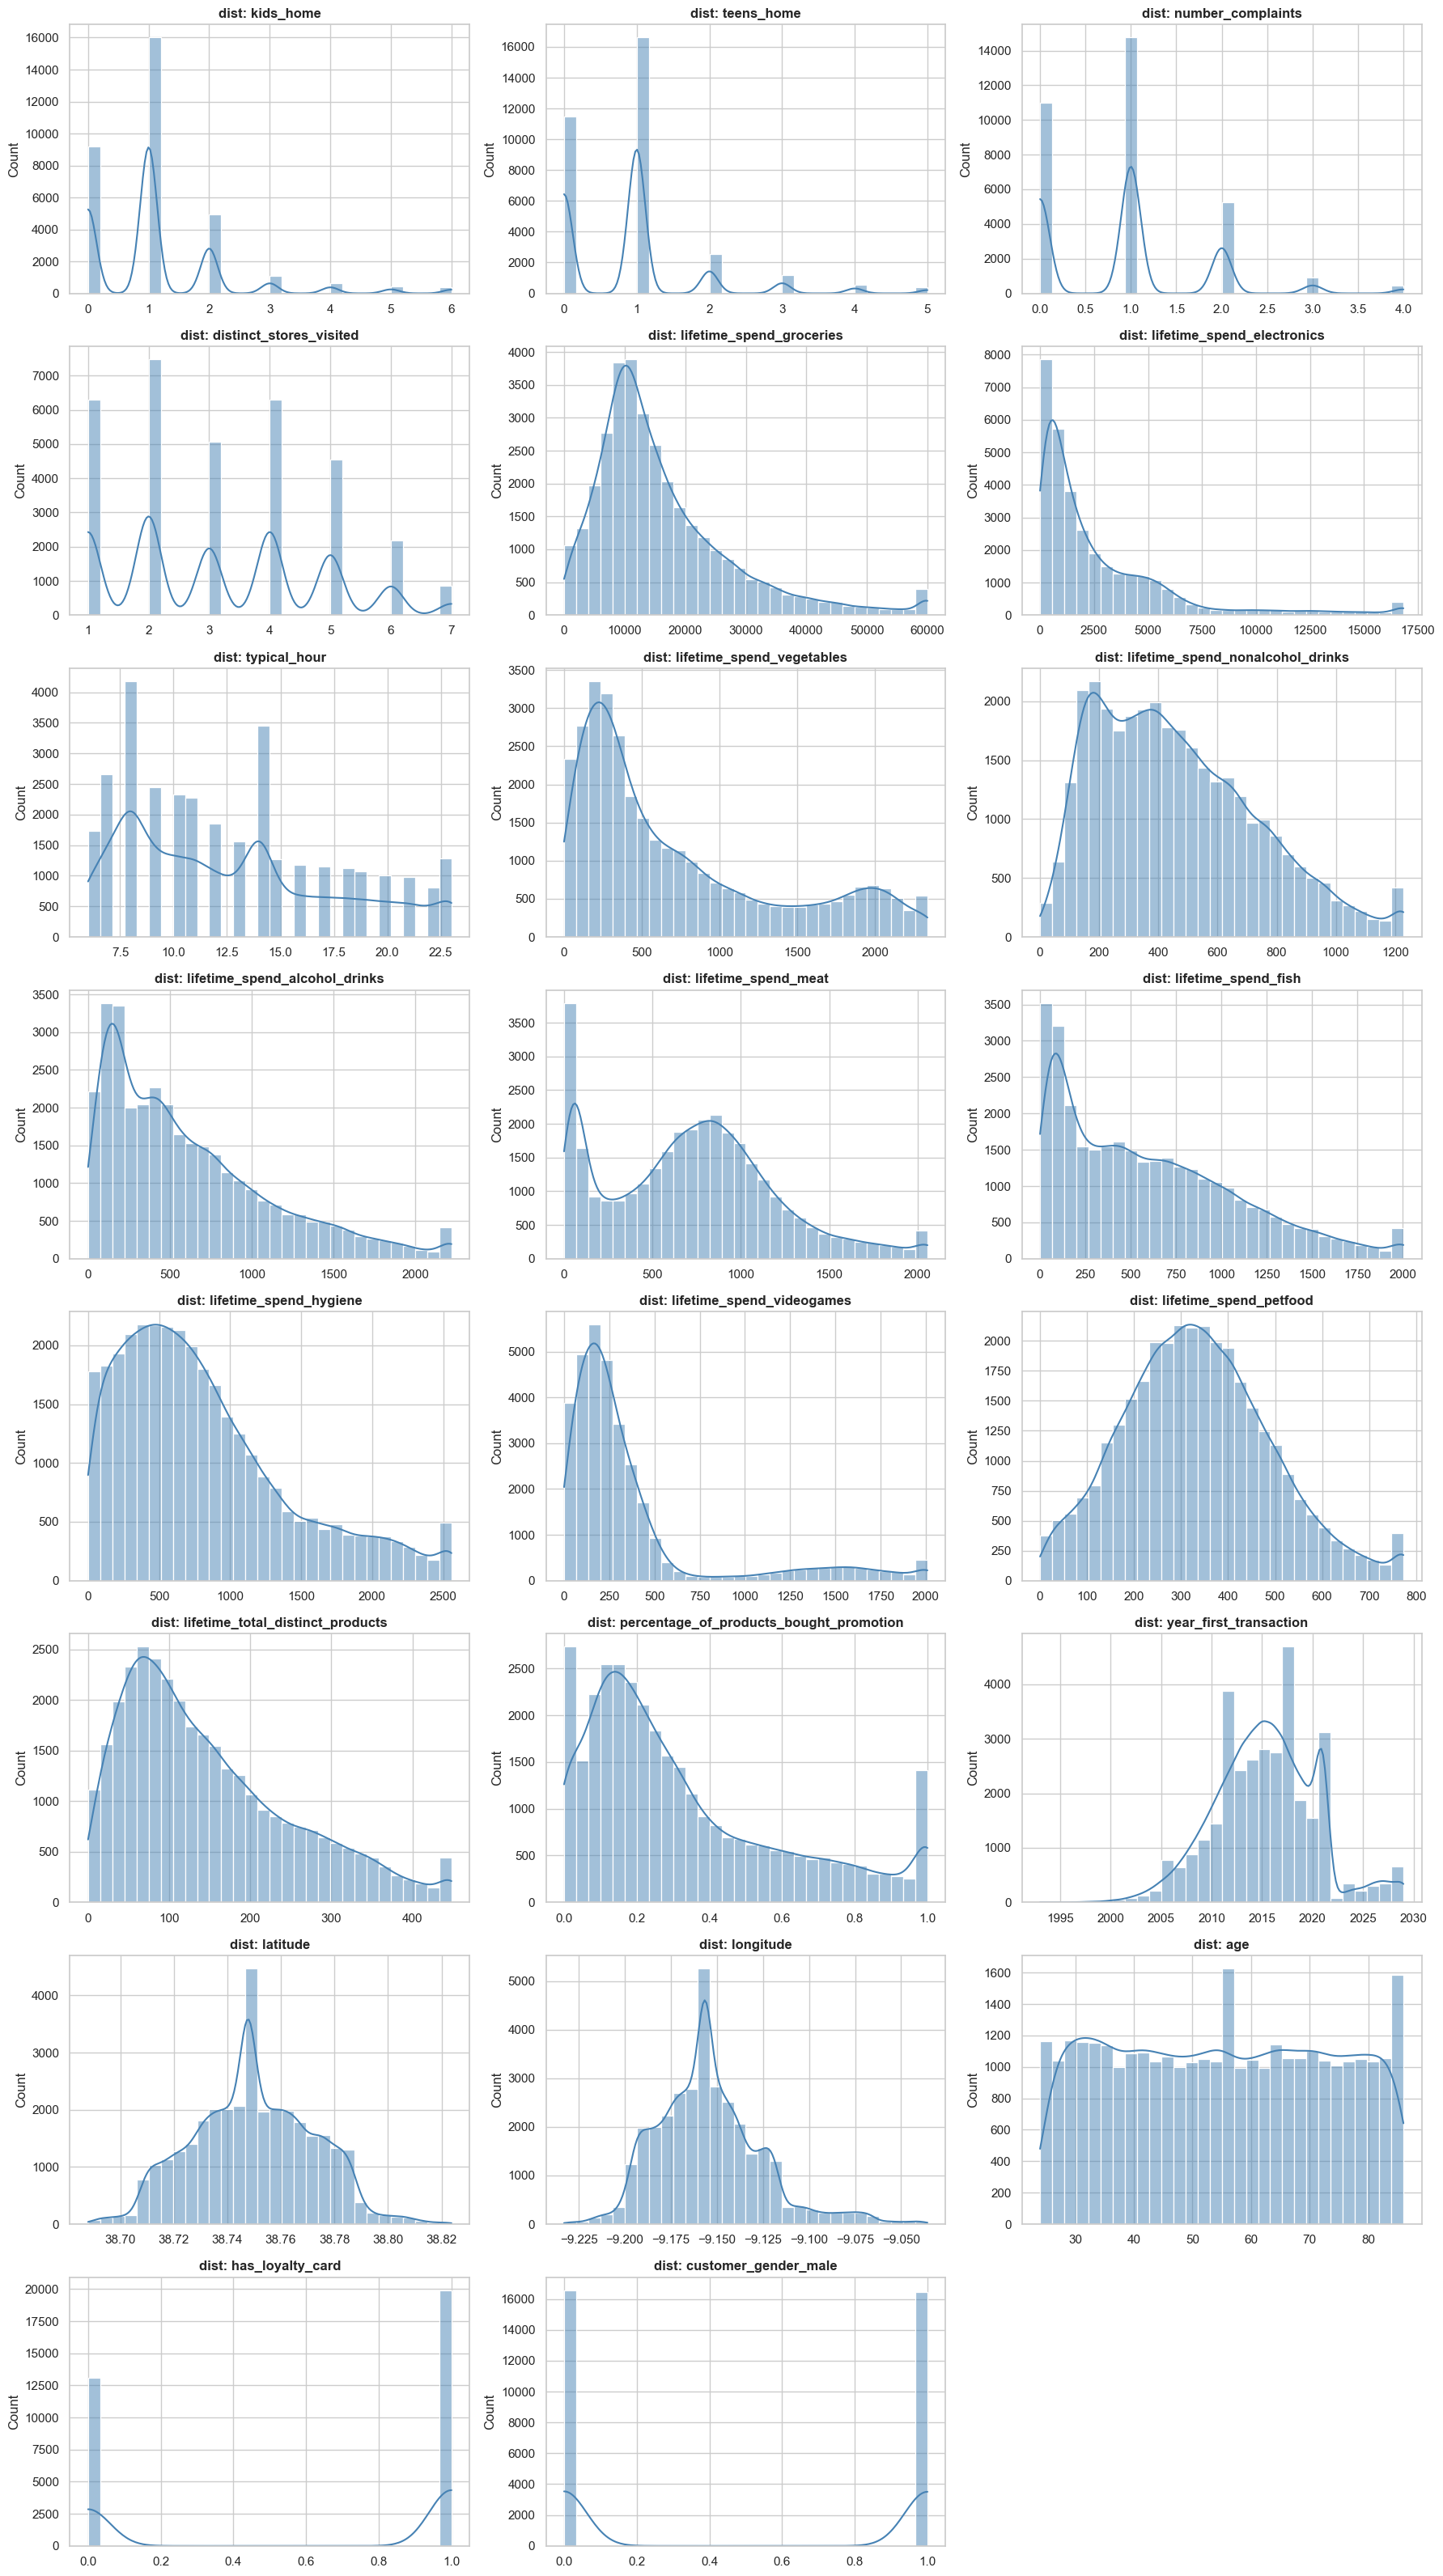

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns
import math

sns.set_theme(style="whitegrid")

# we look at df_clean so it is easier to read
numeric_cols = df_clean.select_dtypes(include=['float64', 'int64', 'int32']).columns

n_cols = 3
n_rows = math.ceil(len(numeric_cols) / n_cols)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 4 * n_rows))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    sns.histplot(data=df_clean, x=col, kde=True, ax=axes[i], bins=30, color='steelblue')

    axes[i].set_title(f'dist: {col}', fontsize=12, fontweight='bold')
    axes[i].set_xlabel('')
    axes[i].set_ylabel('Count')

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

Now we check for multicollinearity:

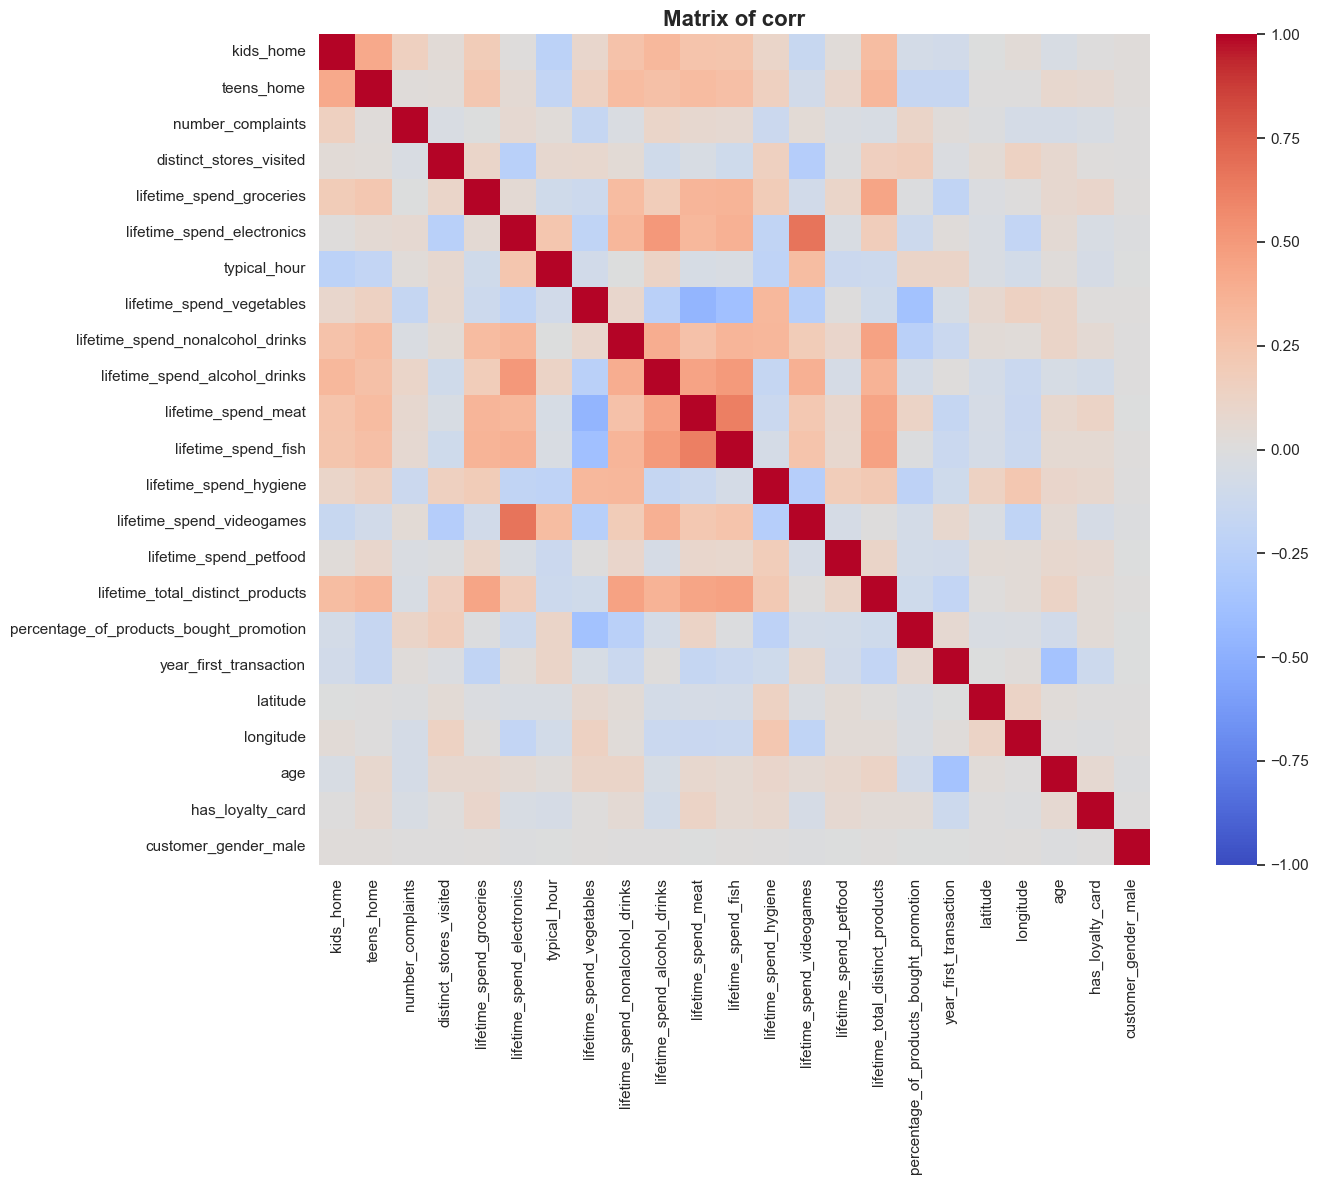

THRESHOLD: 0.85
Col for drop: []


In [11]:

corr_matrix = df_clean.corr()

plt.figure(figsize=(16, 12))

sns.heatmap(corr_matrix, annot=False, cmap='coolwarm', center=0, vmin=-1, vmax=1, square=True)

plt.title('Matrix of corr', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

# If the absolute correlation > 0.85, we treat the features as duplicates
THRESHOLD = 0.85

upper_triangle = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

cols_to_drop_corr = [column for column in upper_triangle.columns if any(upper_triangle[column].abs() > THRESHOLD)]

print(f"THRESHOLD: {THRESHOLD}")
print(f"Col for drop: {cols_to_drop_corr}")
#df_clean = df_clean.drop(columns=cols_to_drop_corr)


### 2. Clustering

In [12]:
from sklearn.cluster import KMeans
k_values = range(2,31)
inertia = []
for k in k_values:
    k_inertia = []
    for i in range(30):
        kmeans = KMeans(n_clusters=k).fit(df_final)
        k_inertia.append(kmeans.inertia_)
    inertia.append(sum(k_inertia)/30)

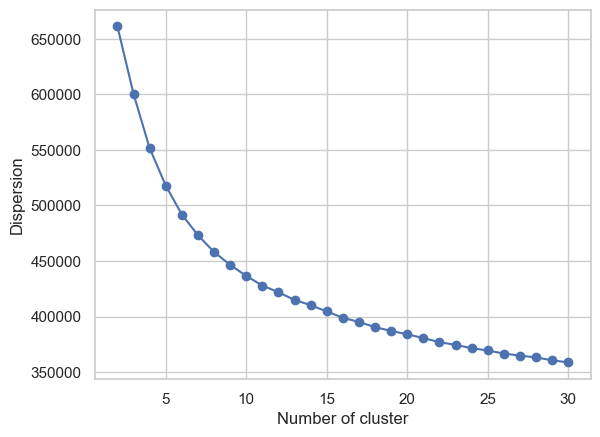

In [13]:
plt.plot(k_values, inertia, marker = "o")
plt.xlabel("Number of cluster")
plt.ylabel("Dispersion")
plt.show()

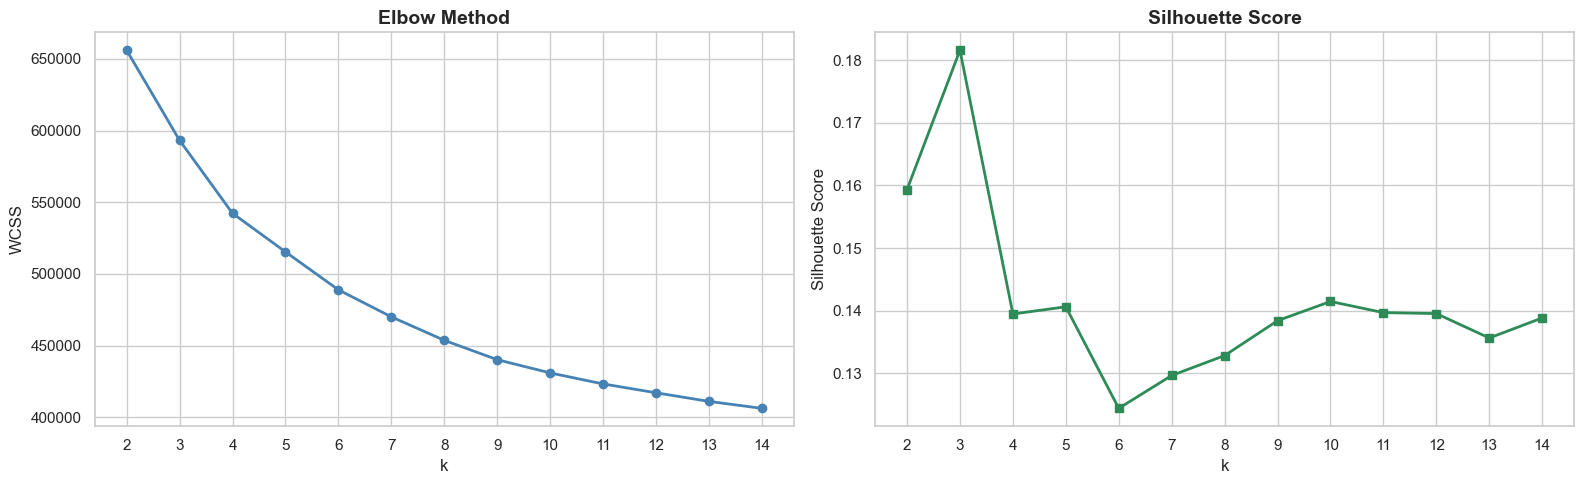

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

k_range = range(2, 15)

inertia = []
silhouette_scores = []
data_for_clustering = df_final

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(data_for_clustering)

    inertia.append(kmeans.inertia_)

    # 2. Silhouette Score (-1 to 1, higher is better)
    labels = kmeans.labels_
    score = silhouette_score(data_for_clustering, labels)
    silhouette_scores.append(score)


sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Elbow Method
axes[0].plot(k_range, inertia, marker='o', color='steelblue', linewidth=2)
axes[0].set_title('Elbow Method', fontsize=14, fontweight='bold')
axes[0].set_xlabel('k', fontsize=12)
axes[0].set_ylabel('WCSS', fontsize=12)
axes[0].set_xticks(k_range)

# Silhouette Score
axes[1].plot(k_range, silhouette_scores, marker='s', color='seagreen', linewidth=2)
axes[1].set_title('Silhouette Score', fontsize=14, fontweight='bold')
axes[1].set_xlabel('k', fontsize=12)
axes[1].set_ylabel('Silhouette Score', fontsize=12)
axes[1].set_xticks(k_range)

plt.tight_layout()
plt.show()

In [15]:
# k=5
kmeans_final = KMeans(n_clusters=5, random_state=42, n_init=10)
cluster_labels = kmeans_final.fit_predict(df_final)

# Attach the results to the readable data
df_analysis = df_clean.copy()
df_analysis['cluster'] = cluster_labels

print("Customer distribution across clusters:")
print(df_analysis['cluster'].value_counts())
print("-" * 50)

# Cluster profiles
cols_to_analyze = [
    'age', 'kids_home', 'teens_home', 'number_complaints', 'typical_hour',
    'distinct_stores_visited', 'lifetime_spend_groceries',
    'lifetime_spend_electronics', 'lifetime_spend_vegetables',
    'lifetime_spend_nonalcohol_drinks', 'lifetime_spend_alcohol_drinks',
    'lifetime_spend_meat', 'lifetime_spend_fish', 'lifetime_spend_hygiene',
    'lifetime_spend_videogames', 'lifetime_spend_petfood',
    'lifetime_total_distinct_products', 'percentage_of_products_bought_promotion',
    'has_loyalty_card', 'cluster'
]

# Safely keep only the columns that actually exist in df_analysis
valid_cols = [col for col in cols_to_analyze if col in df_analysis.columns]

cluster_profiles = df_analysis[valid_cols].groupby('cluster').mean().T
cluster_profiles = cluster_profiles.round(2)

display(cluster_profiles)

Customer distribution across clusters:
cluster
2    13770
1     7189
3     5492
4     3327
0     3260
Name: count, dtype: int64
--------------------------------------------------


cluster,0,1,2,3,4
age,57.39,57.66,50.95,59.91,56.77
kids_home,3.26,1.04,0.89,1.02,0.25
teens_home,2.67,0.88,0.62,0.90,0.31
number_complaints,0.91,0.68,0.94,1.12,1.07
typical_hour,10.08,12.44,11.92,13.39,17.55
distinct_stores_visited,3.19,3.37,3.17,3.88,1.44
lifetime_spend_groceries,25019.05,11456.62,12927.66,29910.06,8814.70
lifetime_spend_electronics,5059.92,1447.23,1001.13,3047.33,9931.17
lifetime_spend_vegetables,835.27,1747.75,437.21,375.82,183.22
lifetime_spend_nonalcohol_drinks,814.12,508.02,256.31,659.27,551.28


### SOM

In [16]:

from minisom import MiniSom
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

data_matrix = df_final.values

# K-Means
kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)
kmeans_labels = kmeans.fit_predict(data_matrix)

kmeans_silhouette = silhouette_score(data_matrix, kmeans_labels)

#SOM
n_samples, n_features = data_matrix.shape

# 5 clusters
som = MiniSom(x=5, y=1, input_len=n_features, sigma=1.0, learning_rate=0.5, random_seed=42)
som.random_weights_init(data_matrix)
som.train_random(data_matrix, num_iteration=10000)
# Best Matching Unit
som_labels = np.array([som.winner(x)[0] for x in data_matrix])

som_silhouette = silhouette_score(data_matrix, som_labels)

# Compare the results
print("Silhouette Score)")
print(f"K-Means (5 k): {kmeans_silhouette:.4f}")
print(f"SOM     (5 k): {som_silhouette:.4f}")


print("\n distribution of people (K-Means):")
print(pd.Series(kmeans_labels).value_counts().sort_index().values)

print("\n distribution of people(SOM):")
print(pd.Series(som_labels).value_counts().sort_index().values)

Silhouette Score)
K-Means (5 k): 0.1406
SOM     (5 k): 0.1354

 distribution of people (K-Means):
[ 3260  7189 13770  5492  3327]

 distribution of people(SOM):
[ 3412  7092  7300 11832  3402]


In [17]:
df_som_analysis = df_clean.copy()
df_som_analysis['cluster_som'] = som_labels

cols_to_analyze_som = [
    'age', 'kids_home', 'teens_home', 'number_complaints', 'typical_hour',
    'distinct_stores_visited', 'lifetime_spend_groceries', 
    'lifetime_spend_electronics', 'lifetime_spend_vegetables',
    'lifetime_spend_nonalcohol_drinks', 'lifetime_spend_alcohol_drinks',
    'lifetime_spend_meat', 'lifetime_spend_fish', 'lifetime_spend_hygiene',
    'lifetime_spend_videogames', 'lifetime_spend_petfood',
    'lifetime_total_distinct_products', 'percentage_of_products_bought_promotion',
    'has_loyalty_card', 'cluster_som'
]

valid_cols_som = [col for col in cols_to_analyze_som if col in df_som_analysis.columns]

som_profiles = df_som_analysis[valid_cols_som].groupby('cluster_som').mean().T
som_profiles = som_profiles.round(2)

display(som_profiles)

cluster_som,0,1,2,3,4
age,58.32,60.32,58.18,48.60,57.19
kids_home,3.14,0.90,1.03,0.94,0.27
teens_home,2.60,0.92,0.87,0.56,0.33
number_complaints,0.95,0.88,0.72,1.02,1.09
typical_hour,10.29,11.17,12.55,12.93,17.47
distinct_stores_visited,3.33,3.01,3.47,3.49,1.51
lifetime_spend_groceries,25013.97,27020.30,11532.03,12169.34,8930.91
lifetime_spend_electronics,4975.86,2464.61,1441.34,1043.11,9724.52
lifetime_spend_vegetables,806.96,448.20,1713.97,412.90,191.31
lifetime_spend_nonalcohol_drinks,823.55,542.47,502.91,260.82,551.40


Unlike K-Means, SOM arranged the customer segments into a logical, continuous gradient (from left to right). It maps a clear customer journey axis: transitioning from early-morning, highly loyal families with large baskets (Cluster 0) to late-evening, non-loyal single shoppers buying specific tech (Cluster 4).

SOM Cluster Profiles:

#### Cluster 0: Wealthy Large Families Early morning shoppers (~10:30) with 3+ kids. 
They are the absolute top spenders, filling huge baskets with groceries, meat, and alcohol.

#### Cluster 1: Loyal Premium Seniors Morning shoppers (~11:00) with the highest loyalty card ownership (73%).
They have few kids at home and spend heavily on premium, everyday groceries.

#### Cluster 2: Vegetarian / Eco-Families Midday shoppers with a highly specific diet.
They spend almost nothing on meat and fish, but heavily dominate spending on vegetables and hygiene products.

#### Cluster 3: Budget-Conscious Deal Hunters Afternoon shoppers (~13:00). 
Their defining characteristic is that 50% of all their purchases are made using promotions and discounts.

#### Cluster 4: Evening Tech-Gamers Late evening shoppers (~17:30). 
Mostly singles/no kids with the lowest loyalty card usage. They spend very little on standard food but have massively high spending on electronics and video games.

### Hierarchical Clustering (benchmark)

Besides K-Means and SOM we also fit agglomerative (hierarchical) clustering. We use it to compare the algorithms and to check the cluster structure with a dendrogram. It is not the final model: SOM stays as the segmentation we use.

Hierarchical clustering scales as O(n^2), so the dendrogram and the linkage comparison (ward, complete, average) are run on a random sample. The chosen ward solution is then refit on the full dataset so its metrics are comparable to K-Means and SOM.

,Linkage,Silhouette (higher=better),Calinski-Harabasz (higher=better),Davies-Bouldin (lower=better)
0,ward,0.1301,556.1745,2.2099
1,complete,0.1012,409.0868,3.0753
2,average,0.1392,141.1199,1.3125


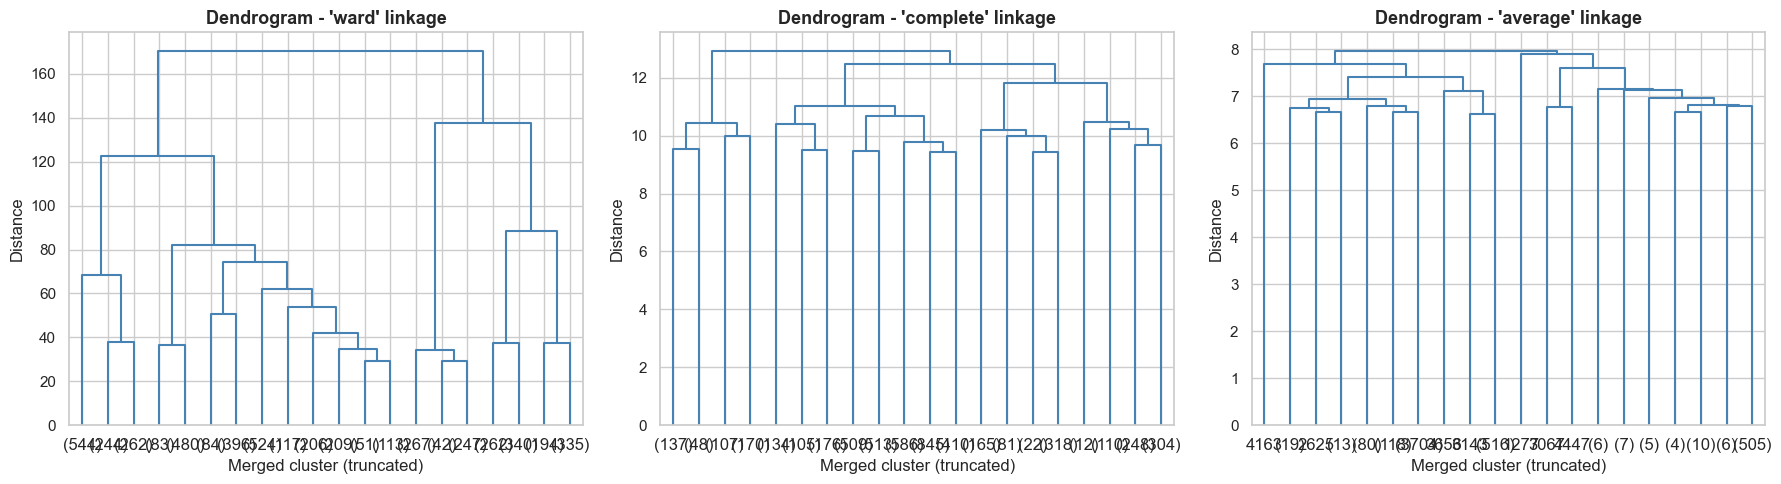

Customer distribution across Hierarchical (Ward) clusters:
cluster_hier
0     6772
1    13203
2     3134
3     3485
4     6444
Name: count, dtype: int64


cluster_hier,0,1,2,3,4
age,60.27,49.49,57.25,57.46,58.93
kids_home,0.81,0.98,0.22,3.10,1.04
teens_home,0.86,0.62,0.30,2.56,0.88
number_complaints,0.66,1.16,1.10,0.92,0.63
typical_hour,10.77,13.22,17.68,10.13,12.46
distinct_stores_visited,2.86,3.61,1.41,3.22,3.36
lifetime_spend_groceries,24669.83,13766.72,8210.99,25135.54,11386.32
lifetime_spend_electronics,2102.23,1381.80,9917.53,5038.27,1445.13
lifetime_spend_vegetables,464.65,460.13,163.39,825.43,1764.13
lifetime_spend_nonalcohol_drinks,517.16,296.34,561.00,810.10,511.21


In [18]:
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score
from scipy.cluster.hierarchy import dendrogram, linkage

NUM_CLUSTERS = 5
linkage_methods = ('ward', 'complete', 'average')

# Reproducible sub-sample for the dendrogram and the linkage comparison
sample_size = min(5000, df_final.shape[0])
sample_idx = np.random.RandomState(42).choice(df_final.shape[0], size=sample_size, replace=False)
sample_matrix = df_final.values[sample_idx]

# 1) Compare linkage strategies on the sample
linkage_results = []
for lk in linkage_methods:
    labels = AgglomerativeClustering(n_clusters=NUM_CLUSTERS, linkage=lk).fit_predict(sample_matrix)
    linkage_results.append({
        'Linkage': lk,
        'Silhouette (higher=better)': silhouette_score(sample_matrix, labels),
        'Calinski-Harabasz (higher=better)': calinski_harabasz_score(sample_matrix, labels),
        'Davies-Bouldin (lower=better)': davies_bouldin_score(sample_matrix, labels),
    })
linkage_results = pd.DataFrame(linkage_results)
display(linkage_results.round(4))

# 2) Dendrograms (truncated to the last 20 merges for readability)
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, len(linkage_methods), figsize=(6 * len(linkage_methods), 5))
for ax, lk in zip(np.atleast_1d(axes), linkage_methods):
    Z = linkage(sample_matrix, method=lk)
    dendrogram(Z, truncate_mode='lastp', p=20, ax=ax, color_threshold=0, above_threshold_color='steelblue')
    ax.set_title(f"Dendrogram - '{lk}' linkage", fontsize=13, fontweight='bold')
    ax.set_xlabel('Merged cluster (truncated)')
    ax.set_ylabel('Distance')
plt.tight_layout()
plt.show()

# 3) Final 'ward' on the FULL dataset -> labels for the model comparison
hier_labels = AgglomerativeClustering(n_clusters=NUM_CLUSTERS, linkage='ward').fit_predict(df_final)

df_hier_analysis = df_clean.copy()
df_hier_analysis['cluster_hier'] = hier_labels
print("Customer distribution across Hierarchical (Ward) clusters:")
print(df_hier_analysis['cluster_hier'].value_counts().sort_index())

profile_cols = [c for c in cols_to_analyze_som if c in df_hier_analysis.columns and c != 'cluster_som']
hier_profiles = df_hier_analysis.groupby('cluster_hier')[profile_cols].mean().T.round(2)
display(hier_profiles)

,Model,Silhouette (higher=better),Calinski-Harabasz (higher=better),Davies-Bouldin (lower=better)
0,K-Means,0.1400,3870.2067,2.2115
1,SOM,0.1349,3785.5356,2.2628
2,Hierarchical (Ward),0.1191,3546.7282,2.3534


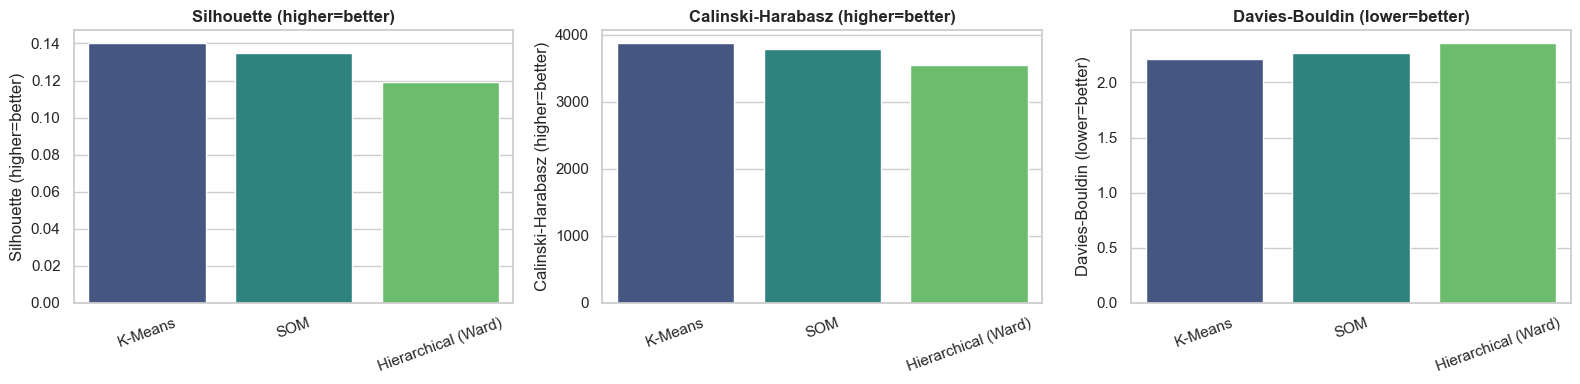

In [19]:
# Compare the three models. Silhouette is computed on a 10k sub-sample (full 33k is O(n^2) in memory)
models_to_compare = {'K-Means': kmeans_labels, 'SOM': som_labels, 'Hierarchical (Ward)': hier_labels}

comparison = []
for name, labels in models_to_compare.items():
    comparison.append({
        'Model': name,
        'Silhouette (higher=better)': silhouette_score(df_final, labels, sample_size=10000, random_state=42),
        'Calinski-Harabasz (higher=better)': calinski_harabasz_score(df_final, labels),
        'Davies-Bouldin (lower=better)': davies_bouldin_score(df_final, labels),
    })
comparison = pd.DataFrame(comparison)
display(comparison.round(4))

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
metric_cols = ['Silhouette (higher=better)', 'Calinski-Harabasz (higher=better)', 'Davies-Bouldin (lower=better)']
for ax, metric in zip(axes, metric_cols):
    sns.barplot(data=comparison, x='Model', y=metric, hue='Model', palette='viridis', legend=False, ax=ax)
    ax.set_title(metric, fontsize=12, fontweight='bold')
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=20)
plt.tight_layout()
plt.show()

### Cluster profiles: radar, heatmap and demographics

A few views of the final SOM segmentation: a spend radar by category, a heatmap of average spend, and a comparison of demographics and behaviour across clusters.

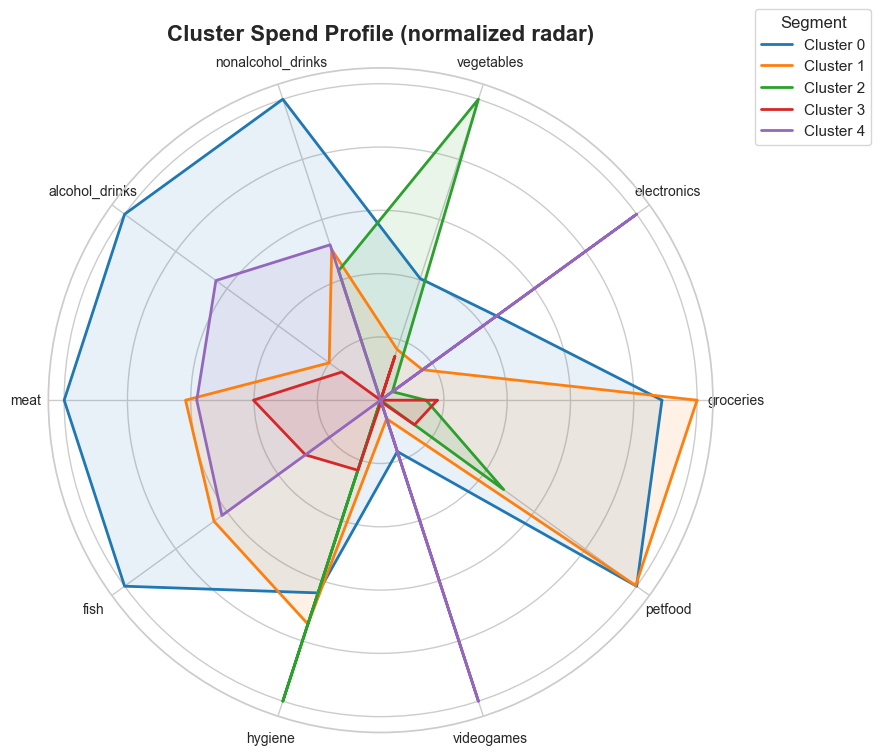

In [20]:
# Radar: normalized spend profile per category for each cluster
spend_cols = [c for c in df_som_analysis.columns if c.startswith('lifetime_spend_')]
profiles = df_som_analysis.groupby('cluster_som')[spend_cols].mean()
norm = (profiles - profiles.min()) / (profiles.max() - profiles.min()).replace(0, 1)

labels_r = [c.replace('lifetime_spend_', '') for c in spend_cols]
angles = np.linspace(0, 2 * np.pi, len(labels_r), endpoint=False).tolist()
angles += angles[:1]

fig, ax = plt.subplots(figsize=(9, 9), subplot_kw=dict(polar=True))
palette = sns.color_palette('tab10', n_colors=len(norm.index))
for color, (cid, row) in zip(palette, norm.iterrows()):
    vals = row.tolist() + [row.tolist()[0]]
    ax.plot(angles, vals, linewidth=2, label=f'Cluster {cid}', color=color)
    ax.fill(angles, vals, alpha=0.10, color=color)
ax.set_xticks(angles[:-1])
ax.set_xticklabels(labels_r, fontsize=10)
ax.set_yticklabels([])
ax.set_title('Cluster Spend Profile (normalized radar)', fontsize=16, fontweight='bold', pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.25, 1.10), title='Segment')
plt.tight_layout()
plt.show()

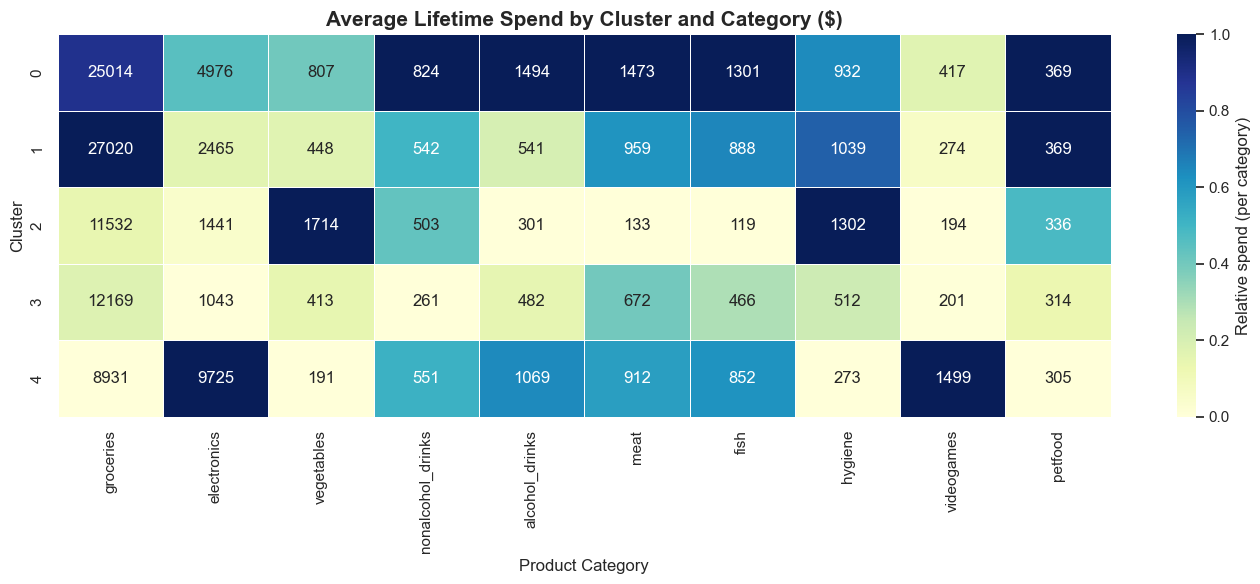

In [21]:
# Heatmap of average spend (color normalized per category, annotations show real $)
spend_cols = [c for c in df_som_analysis.columns if c.startswith('lifetime_spend_')]
profiles = df_som_analysis.groupby('cluster_som')[spend_cols].mean()
profiles.columns = [c.replace('lifetime_spend_', '') for c in spend_cols]
col_norm = (profiles - profiles.min()) / (profiles.max() - profiles.min()).replace(0, 1)

plt.figure(figsize=(14, 6))
sns.heatmap(col_norm, annot=profiles.round(0).astype(int), fmt='d', cmap='YlGnBu',
            cbar_kws={'label': 'Relative spend (per category)'}, linewidths=0.5)
plt.title('Average Lifetime Spend by Cluster and Category ($)', fontsize=15, fontweight='bold')
plt.xlabel('Product Category')
plt.ylabel('Cluster')
plt.tight_layout()
plt.show()

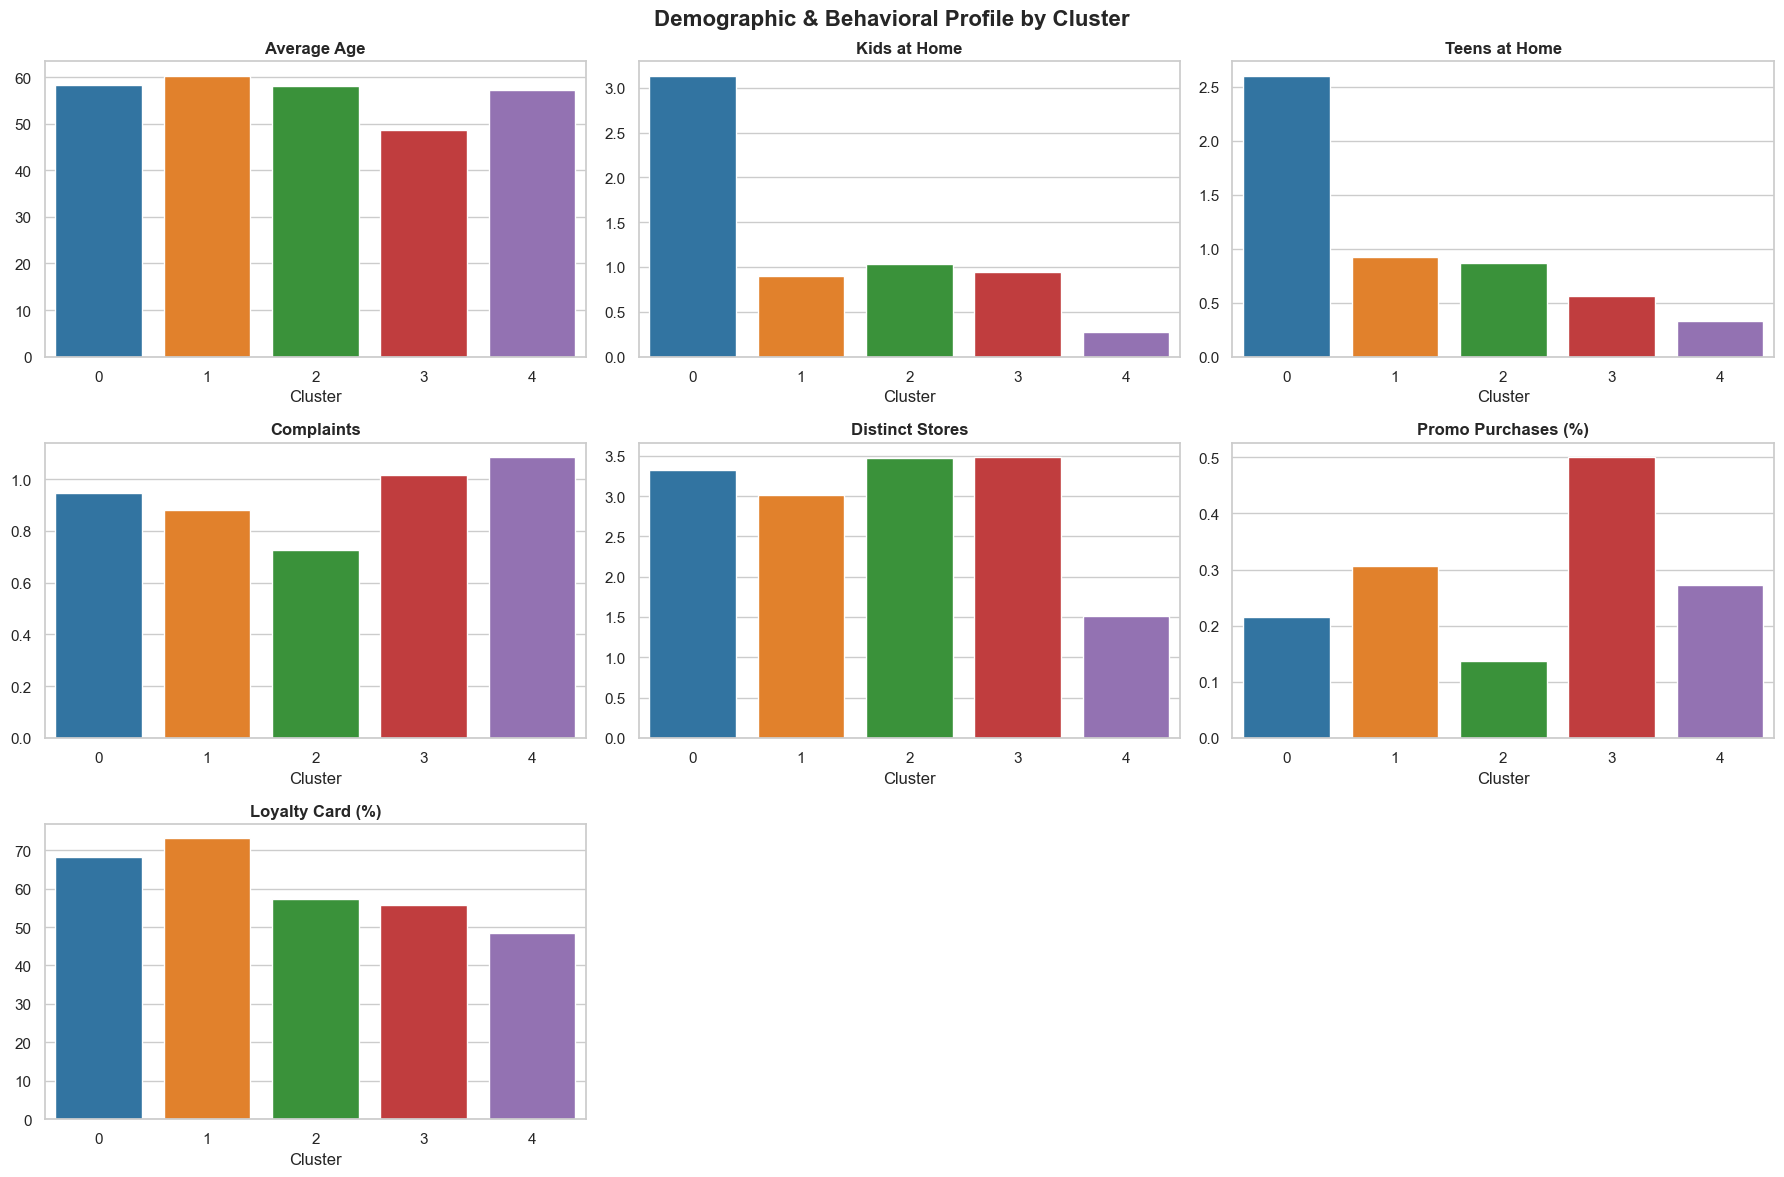

In [22]:
# Demographic / behavioural comparison across clusters (small multiples - metrics have different scales)
metrics = {'age': 'Average Age', 'kids_home': 'Kids at Home', 'teens_home': 'Teens at Home',
           'number_complaints': 'Complaints', 'distinct_stores_visited': 'Distinct Stores',
           'percentage_of_products_bought_promotion': 'Promo Purchases (%)'}
if 'has_loyalty_card' in df_som_analysis.columns:
    metrics['has_loyalty_card'] = 'Loyalty Card (%)'

valid = {k: v for k, v in metrics.items() if k in df_som_analysis.columns}
summary = df_som_analysis.groupby('cluster_som')[list(valid.keys())].mean()
if 'has_loyalty_card' in summary.columns:
    summary['has_loyalty_card'] = summary['has_loyalty_card'] * 100

sns.set_theme(style="whitegrid")
n_cols = 3
n_rows = math.ceil(len(valid) / n_cols)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(6 * n_cols, 4 * n_rows))
axes = np.atleast_1d(axes).flatten()
palette = sns.color_palette('tab10', n_colors=len(summary.index))
for ax, (col, title) in zip(axes, valid.items()):
    sns.barplot(x=summary.index, y=summary[col], hue=summary.index, palette=palette, legend=False, ax=ax)
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xlabel('Cluster')
    ax.set_ylabel('')
for j in range(len(valid), len(axes)):
    fig.delaxes(axes[j])
plt.suptitle('Demographic & Behavioral Profile by Cluster', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

--------------------------------- PCA----------------------------

C:\Users\vgvoz\AppData\Local\Temp\ipykernel_30556\1495912975.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=som_counts.index, y=som_counts.values, ax=axes[0], palette="coolwarm")


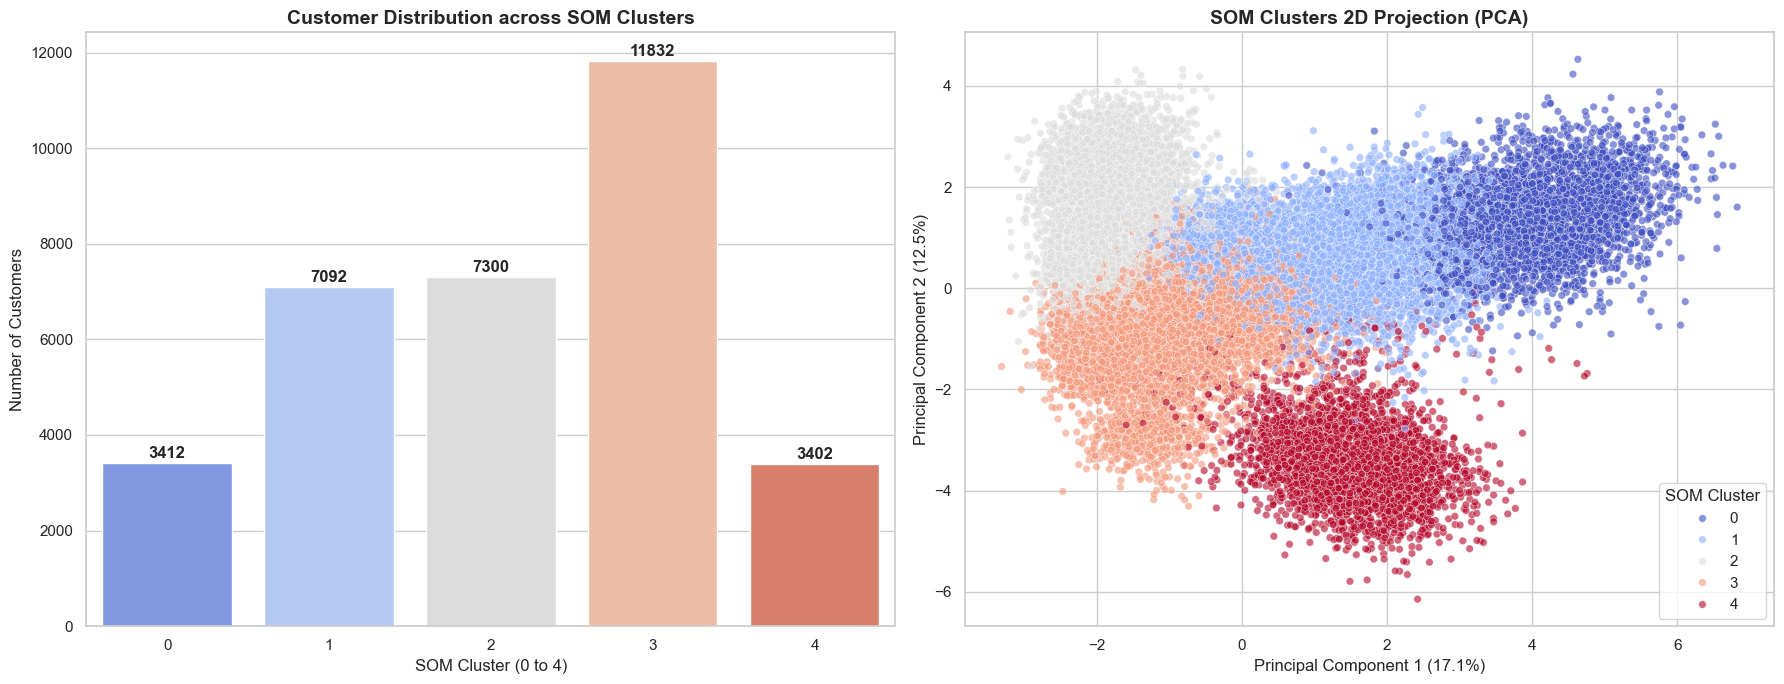

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
import pandas as pd

sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(18, 7))


# Distribution of people across clusters
som_counts = pd.Series(som_labels).value_counts().sort_index()
sns.barplot(x=som_counts.index, y=som_counts.values, ax=axes[0], palette="coolwarm")
axes[0].set_title('Customer Distribution across SOM Clusters', fontsize=14, fontweight='bold')
axes[0].set_xlabel('SOM Cluster (0 to 4)', fontsize=12)
axes[0].set_ylabel('Number of Customers', fontsize=12)

for i, v in enumerate(som_counts.values):
    axes[0].text(i, v + 100, str(v), ha='center', fontweight='bold')

# PCA

pca = PCA(n_components=2, random_state=42)
data_pca = pca.fit_transform(df_final)

df_viz = pd.DataFrame(data_pca, columns=['PCA1', 'PCA2'])
df_viz['Cluster_SOM'] = som_labels

scatter = sns.scatterplot(
    data=df_viz, 
    x='PCA1', y='PCA2', 
    hue='Cluster_SOM', 
    palette='coolwarm', 
    alpha=0.6, 
    s=30,      
    ax=axes[1]
)

axes[1].set_title('SOM Clusters 2D Projection (PCA)', fontsize=14, fontweight='bold')
axes[1].set_xlabel(f'Principal Component 1 ({pca.explained_variance_ratio_[0]*100:.1f}%)', fontsize=12)
axes[1].set_ylabel(f'Principal Component 2 ({pca.explained_variance_ratio_[1]*100:.1f}%)', fontsize=12)
axes[1].legend(title='SOM Cluster', loc='best')

plt.tight_layout()
plt.show()

c:\Users\vgvoz\anaconda3\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


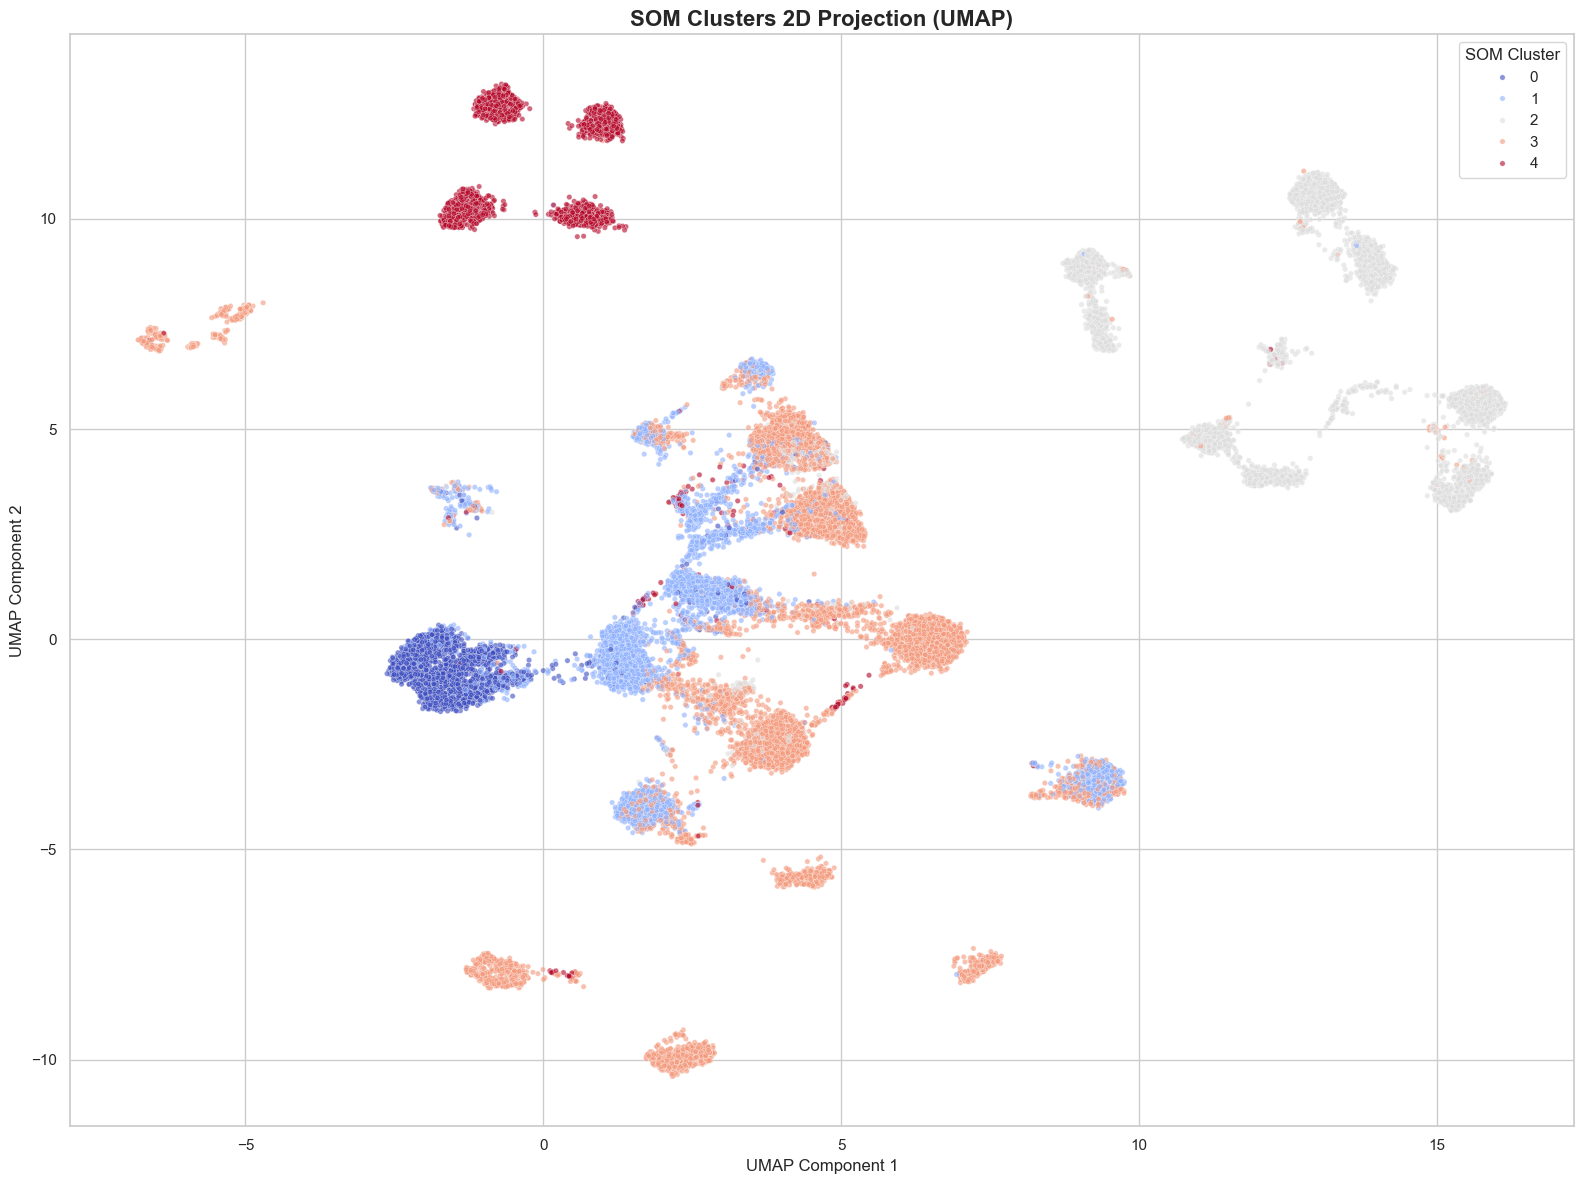

In [24]:
import umap  
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

sns.set_theme(style="whitegrid")
plt.figure(figsize=(16, 12))

#  UMAP
reducer = umap.UMAP(n_neighbors=15, min_dist=0.1, random_state=42)
data_umap = reducer.fit_transform(df_final)

df_viz_umap = pd.DataFrame(data_umap, columns=['UMAP1', 'UMAP2'])
df_viz_umap['Cluster_SOM'] = som_labels

scatter = sns.scatterplot(
    data=df_viz_umap, 
    x='UMAP1', y='UMAP2', 
    hue='Cluster_SOM', 
    palette='coolwarm', 
    alpha=0.6, 
    s=15  
)

plt.title('SOM Clusters 2D Projection (UMAP)', fontsize=16, fontweight='bold')
plt.xlabel('UMAP Component 1', fontsize=12)
plt.ylabel('UMAP Component 2', fontsize=12)
plt.legend(title='SOM Cluster', loc='best')

plt.tight_layout()
plt.show()

c:\Users\vgvoz\anaconda3\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


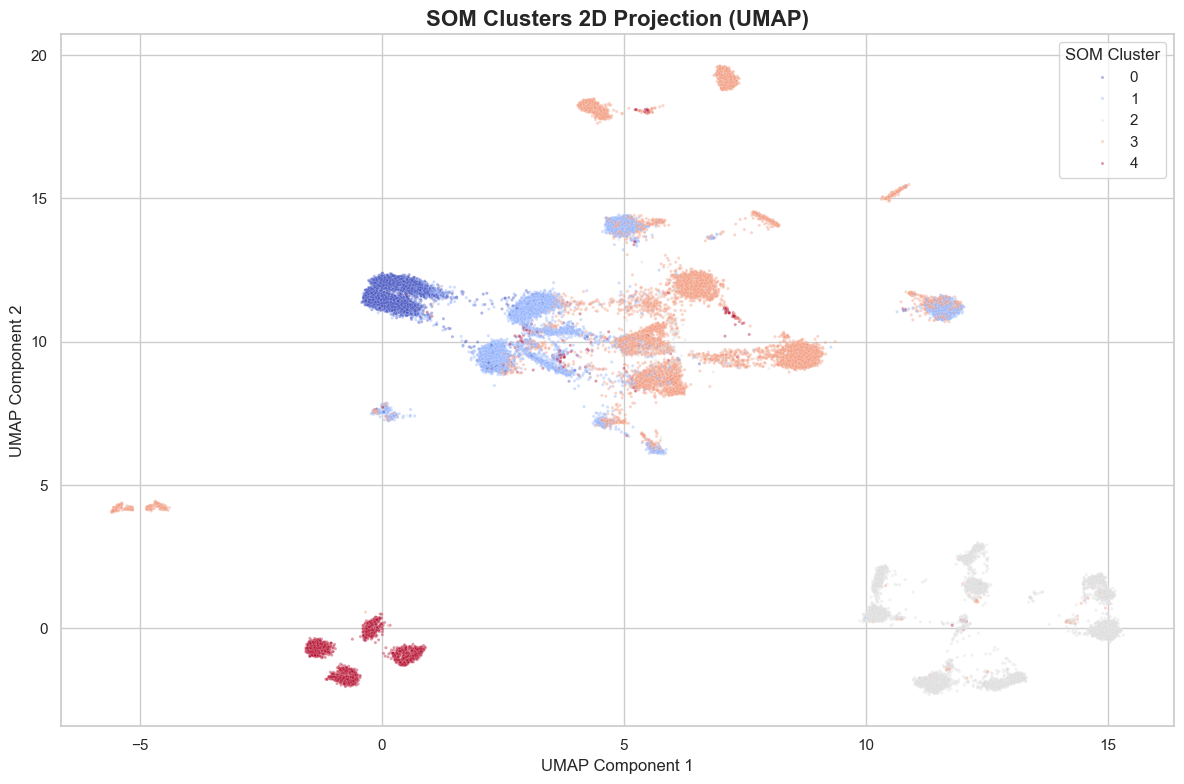

In [25]:
# global view
reducer = umap.UMAP(n_neighbors=50, min_dist=0.05, random_state=42)

sns.set_theme(style="whitegrid")
plt.figure(figsize=(12, 8))

reducer = umap.UMAP(n_neighbors=50, min_dist=0.05, random_state=42)
data_umap = reducer.fit_transform(df_final)

df_viz_umap = pd.DataFrame(data_umap, columns=['UMAP1', 'UMAP2'])
df_viz_umap['Cluster_SOM'] = som_labels

scatter = sns.scatterplot(
    data=df_viz_umap,
    x='UMAP1', y='UMAP2',
    hue='Cluster_SOM',
    palette='coolwarm',
    alpha=0.4,
    s=5
)

plt.title('SOM Clusters 2D Projection (UMAP)', fontsize=16, fontweight='bold')
plt.xlabel('UMAP Component 1', fontsize=12)
plt.ylabel('UMAP Component 2', fontsize=12)
plt.legend(title='SOM Cluster', loc='best')

plt.tight_layout()
plt.show()

### Recommendations: what to buy

In [26]:
df_basket = pd.read_csv('customer_basket.csv')
df_basket.head()

,invoice_id,list_of_goods,customer_id
0,3700630,"['chicken', 'rice', 'pepper', 'whole wheat ric...",12912
1,10242376,"['low fat yogurt', 'tomatoes', 'pepper', 'aspa...",22853
2,91550,"['cake', 'tomatoes', 'pancakes', 'iPad', 'fina...",19
3,3137503,"['cereals', 'megaman zero', 'final fantasy XIX...",10995
4,7165061,"['rice', 'frozen smoothie', 'black tea', 'tea'...",27807


In [27]:
import ast
import pandas as pd
from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import apriori, association_rules

if isinstance(df_basket['list_of_goods'].iloc[0], str):
    df_basket['list_of_goods'] = df_basket['list_of_goods'].apply(ast.literal_eval)

df_merged = df_basket[['customer_id', 'invoice_id', 'list_of_goods']].merge(
    df_som_analysis[['cluster_som']], 
    on='customer_id', 
    how='inner')

def get_recommendations_for_cluster(cluster_id, min_sup=0.02, min_conf=0.2):
    print(f"--- Analyzing Cluster {cluster_id} ")
    
    cluster_baskets = df_merged[df_merged['cluster_som'] == cluster_id]['list_of_goods']
    
    if len(cluster_baskets) == 0:
        print("No data for this cluster.")
        return None
    
    te = TransactionEncoder()
    te_ary = te.fit(cluster_baskets).transform(cluster_baskets)
    df_transactions = pd.DataFrame(te_ary, columns=te.columns_)
    frequent_itemsets = apriori(df_transactions, min_support=min_sup, use_colnames=True)
    rules = association_rules(frequent_itemsets, metric="confidence", min_threshold=min_conf)
    rules = rules[rules['lift'] > 1.2]
    rules = rules.sort_values(by=['lift', 'confidence'], ascending=[False, False])

    rules['antecedents'] = rules['antecedents'].apply(lambda x: ', '.join(list(x)))
    rules['consequents'] = rules['consequents'].apply(lambda x: ', '.join(list(x)))
    
    print(f"Rules found: {len(rules)}")
    return rules[['antecedents', 'consequents', 'support', 'confidence', 'lift']].head(10)

cluster_rules = {}

for i in range(5):
    # min_sup=0.02: the itemset must appear in at least 2% of the transactions for this cluster
    # min_conf=0.2: if item A is bought, item B is bought in at least 20% of the cases
    rules = get_recommendations_for_cluster(cluster_id=i, min_sup=0.02, min_conf=0.2)
    
    if rules is not None:
        cluster_rules[i] = rules
        display(rules)

--- Analyzing Cluster 0 
Rules found: 113


,antecedents,consequents,support,confidence,lift
311,"oatmeal, butter",milk,0.021051,0.262701,1.320851
372,"oatmeal, cereals",milk,0.022441,0.260069,1.307616
374,"cereals, milk",oatmeal,0.022441,0.275610,1.306811
325,"green tea, eggs",cereals,0.021448,0.474725,1.306273
324,"cereals, green tea",eggs,0.021448,0.458599,1.300633
266,"honey, butter",eggs,0.036938,0.457002,1.296106
401,"oatmeal, eggs",honey,0.022937,0.269231,1.291154
414,"honey, fresh bread",oatmeal,0.022341,0.272068,1.290016
296,"butter, salt",fresh bread,0.025320,0.463636,1.287723
416,"honey, fresh bread",tea,0.021746,0.264813,1.284029


--- Analyzing Cluster 1 
Rules found: 2


,antecedents,consequents,support,confidence,lift
1,energy drink,airpods,0.023581,0.308907,2.161204
0,bluetooth headphones,airpods,0.022183,0.303230,2.121485


--- Analyzing Cluster 2 
Rules found: 40


,antecedents,consequents,support,confidence,lift
26,cooking oil,napkins,0.039908,0.301088,2.210130
27,napkins,cooking oil,0.039908,0.292941,2.210130
4,cooking oil,babies food,0.040613,0.306409,2.074443
3,babies food,cooking oil,0.040613,0.274957,2.074443
10,napkins,babies food,0.041671,0.305882,2.070879
9,babies food,napkins,0.041671,0.282118,2.070879
33,napkins,dog food,0.043049,0.316000,1.968108
32,dog food,napkins,0.043049,0.268117,1.968108
22,dog food,cooking oil,0.041286,0.257137,1.940002
23,cooking oil,dog food,0.041286,0.311487,1.940002


--- Analyzing Cluster 3 
Rules found: 102


,antecedents,consequents,support,confidence,lift
76,"avocado, asparagus",salad,0.021541,0.414698,3.924784
79,salad,"avocado, asparagus",0.021541,0.203871,3.924784
92,"spinach, asparagus",salad,0.021882,0.408917,3.870072
95,salad,"spinach, asparagus",0.021882,0.207097,3.870072
86,"carrots, asparagus",salad,0.020621,0.406859,3.850597
78,"asparagus, salad",avocado,0.021541,0.407479,3.762993
96,"tomatoes, asparagus",salad,0.020348,0.391475,3.704999
81,"spinach, asparagus",avocado,0.021200,0.396178,3.658633
75,"asparagus, carrots",avocado,0.020076,0.396100,3.657905
85,"tomatoes, asparagus",avocado,0.020382,0.392131,3.621258


--- Analyzing Cluster 4 
Rules found: 1375


,antecedents,consequents,support,confidence,lift
0,bluetooth headphones,airpods,0.031308,0.469671,3.886682
1,airpods,bluetooth headphones,0.031308,0.259082,3.886682
53,bluetooth headphones,energy drink,0.020448,0.306759,3.713716
54,energy drink,bluetooth headphones,0.020448,0.247552,3.713716
4,energy drink,airpods,0.034658,0.419580,3.472168
3,airpods,energy drink,0.034658,0.286807,3.472168
5,iphone 10,airpods,0.020910,0.404018,3.343383
1234,"deodorant, protein bar","shampoo, tooth brush",0.023914,0.259074,1.741105
1388,"protein bar, shower gel","shampoo, tooth brush",0.023221,0.251880,1.692757
1235,"shampoo, protein bar","deodorant, tooth brush",0.023914,0.250302,1.686083


### Cluster 0: "Breakfast" (113 rules)
Bought together: butter + oatmeal -> milk; green tea + eggs -> cereal; fresh bread + honey -> tea.

#### Promotions:

Combo: "buy eggs and butter, get 20% off fresh bread".

Mailing: an email with breakfast recipes and a promo code for an "oatmeal + honey + milk" set.

### Cluster 1: "Youth / On the go" (only 2 rules)
Bought together: energy drinks -> AirPods; Bluetooth headphones -> AirPods.

The high lift (> 2.1) shows this link is very strong.

#### Promotions:

Trigger: when any headphones are added to the online cart, offer a free energy drink.

### Cluster 2: "Families with pets" (40 rules)
Bought together: baby food -> cooking oil; baby food -> paper napkins; dog food -> napkins.

When there are kids or pets at home, napkins and basics run out fast.

#### Promotions:

Bundles: a "family basket" promo. Buy baby food and dog food, get a large pack of napkins at 30% off.

Reminders: send a promo code for their repeat purchase every 2-3 weeks.

### Cluster 3: "Healthy and vegetarians" (102 rules)
Bought together: avocado + asparagus -> salad; asparagus + spinach -> salad; carrot + asparagus -> avocado.

The confidence is around 40%, which is very high for retail.

#### Promotions:

Discounts: 20% off avocados when buying fresh asparagus and spinach.

Newsletters: send fresh farm-vegetable arrivals to this group. There is no need to offer them meat; they convert best on greens.

### Cluster 4: "Tech and athletes" (1375 rules)
Bought together: AirPods -> Bluetooth headphones; energy drink -> AirPods; protein bar + deodorant -> shampoo and toothbrush.

#### Promotions:

Sports set: a "post-workout" promo code (shampoo + deodorant + protein bar).

Upsell: when someone buys an expensive smartphone (iPhone 10), automatically give a coupon for wireless headphones.

### Final file: cluster assignments

We save the required customer_cluster_assignments.csv with every customer_id and its cluster (from the final SOM model). Every customer is included.

In [28]:
# Required deliverable: customer_id -> cluster for every customer
assignments = df_som_analysis[['cluster_som']].copy()
assignments.index.name = 'customer_id'
assignments = assignments.rename(columns={'cluster_som': 'cluster'})
assignments.to_csv('customer_cluster_assignments.csv')
print(f"Saved {len(assignments)} assignments to 'customer_cluster_assignments.csv'")
assignments.head()

Saved 33038 assignments to 'customer_cluster_assignments.csv'


,cluster
customer_id,
3,3
4,2
5,3
7,4
8,4
